In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
data_path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

titanic_data = pd.read_csv(data_path, index_col='PassengerId')

In [100]:
age_prob = titanic_data['Age'].value_counts(normalize=True)
missing_age = titanic_data['Age'].isna()
age_prob.index
titanic_data.loc[missing_age,'Age']=np.random.choice(age_prob.index, size=missing_age.sum(), p=age_prob.values)


Wypełniam puste dane w kategorii 'Age' randomowymi wiekami z przedziału i prawdopodobieństwem wystąpienia.

In [101]:
top_embarked=titanic_data['Embarked'].value_counts().nlargest(n=1)
titanic_data['Embarked']=titanic_data['Embarked'].fillna(top_embarked.index[0])


Wypełniam puste pola w 'Embarked' najczęstszą daną, bo są tylko 2 puste na 891 rzędów.

In [102]:
fare_prob = titanic_data['Fare'].value_counts(normalize=True)
missing_fare = titanic_data['Fare'].isna()
titanic_data.loc[missing_fare,'Fare']=np.random.choice(fare_prob.index, size=missing_fare.sum(), p=fare_prob.values)
titanic_data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


Wypełniam puste pola w 'Fare' tak samo jak w age bo są wartości skrajne i nie ma rozkładu normalnego.

In [103]:
titanic_data['Cabin']=titanic_data['Cabin'].fillna('Unknown')

Wypełniam nan w 'Cabin' nową kategorią 'Unknown' bo jest ich 687/891, więc większość jest nie wypełniona i wartości rzadko się powtarzają.

In [104]:
titanic_data['Adult'] = 0
titanic_data.loc[titanic_data.Age >= 18, 'Adult'] = 1

family_count = lambda x: x['Parch'] + x['SibSp']
titanic_data['Family'] = titanic_data.apply(family_count, axis=1)
titanic_data.loc[:,'SibSp':'Family']

,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Adult,Family
PassengerId,,,,,,,,
1,1,0,A/5 21171,7.2500,Unknown,S,1,1
2,1,0,PC 17599,71.2833,C85,C,1,1
3,0,0,STON/O2. 3101282,7.9250,Unknown,S,1,0
4,1,0,113803,53.1000,C123,S,1,1
5,0,0,373450,8.0500,Unknown,S,1,0
...,...,...,...,...,...,...,...,...
887,0,0,211536,13.0000,Unknown,S,1,0
888,0,0,112053,30.0000,B42,S,1,0
889,1,2,W./C. 6607,23.4500,Unknown,S,1,3


Tworzę nową kategorię 'Adult', która przechowuje informację czy osoba jest pełnoletnia (1) lub nie (0). Oraz tworzę nową kolumnę 'Family' która przechowuje sumę rodzeństwa oraz rodziców i dzieci dla danej osoby.

In [105]:
categories = titanic_data.select_dtypes(include=['object'])
categories

,Name,Sex,Ticket,Cabin,Embarked
PassengerId,,,,,
1,"Braund, Mr. Owen Harris",male,A/5 21171,Unknown,S
2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
3,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,Unknown,S
4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
5,"Allen, Mr. William Henry",male,373450,Unknown,S
...,...,...,...,...,...
887,"Montvila, Rev. Juozas",male,211536,Unknown,S
888,"Graham, Miss. Margaret Edith",female,112053,B42,S
889,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,Unknown,S


In [106]:
one_hot_encoded = pd.get_dummies(data=titanic_data, columns=['Sex'], dtype=np.int8)
one_hot_encoded = pd.get_dummies(data=one_hot_encoded, columns=['Embarked'], dtype=np.int8)
one_hot_encoded.head(n=5)

top_9=one_hot_encoded.Cabin.value_counts().nlargest(n=9)
is_in_top_9 = one_hot_encoded.Cabin.isin(top_9.index)
is_in_top_9

one_hot_encoded.loc[:, 'Cabin'] = one_hot_encoded.Cabin.where(cond=is_in_top_9, other='Other')
one_hot_encoded = pd.get_dummies(data=one_hot_encoded, columns=['Cabin'], dtype=np.int8)

labels = one_hot_encoded.Ticket.unique()

labels_mapping = {
    k: i for i, k in enumerate(labels.tolist())
}
one_hot_encoded['ticket_label'] = one_hot_encoded.Ticket.apply(lambda x: labels_mapping[x])

one_hot_encoded.head(5)


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Adult,Family,...,Cabin_C22 C26,Cabin_C23 C25 C27,Cabin_D,Cabin_E101,Cabin_F2,Cabin_F33,Cabin_G6,Cabin_Other,Cabin_Unknown,ticket_label
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,1,1,...,0,0,0,0,0,0,0,0,1,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,1,...,0,0,0,0,0,0,0,1,0,1
3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,...,0,0,0,0,0,0,0,0,1,2
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,1,...,0,0,0,0,0,0,0,1,0,3
5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,...,0,0,0,0,0,0,0,0,1,4


One hot encoduje sex i embarked bo jest tam mało różnych wartości, w Cabin większość wartości występuje jednorazowo więc stamtąd biorę 9 najczęstszych, a resztę robię jako other i to też one hot, 'Ticket' też mało się powtarza i tam nie brakowało żadnych danych, więc encoduję po labels, a imię i nazwisko zostawiam tak jak jest.

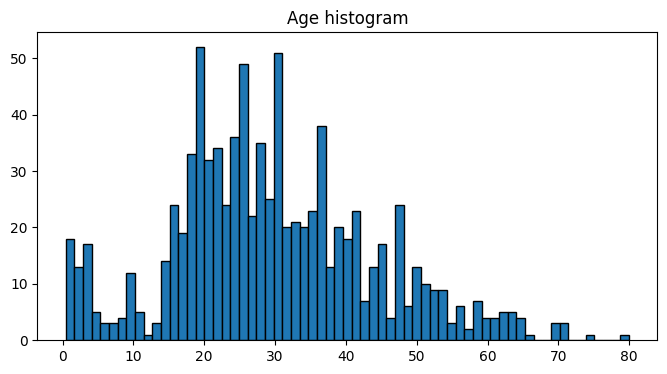

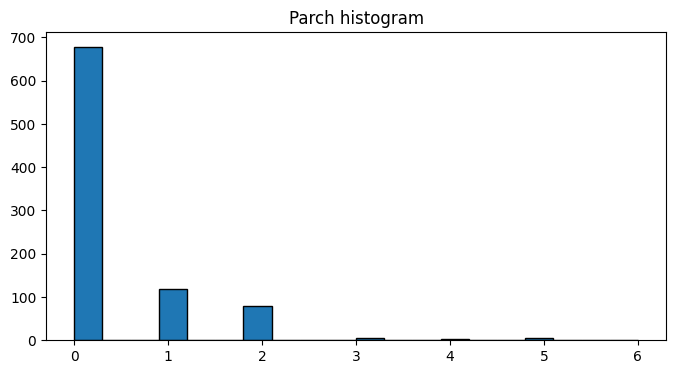

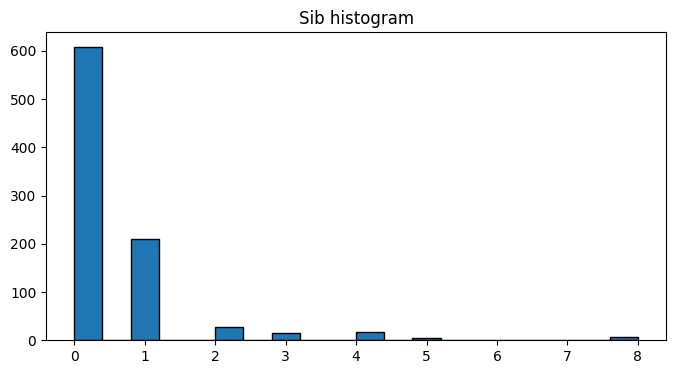

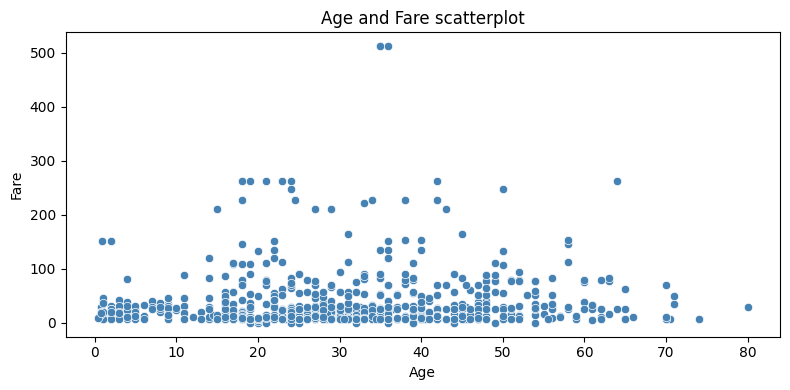

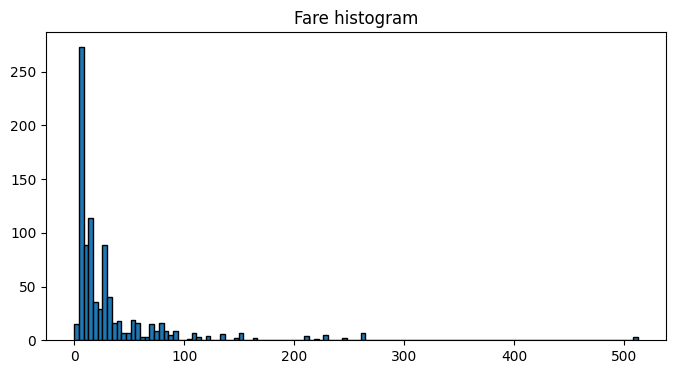

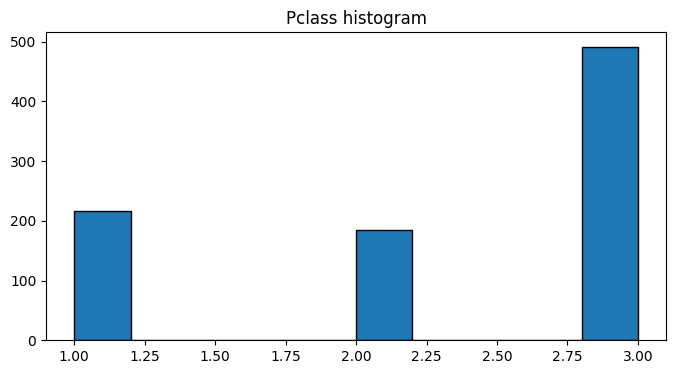

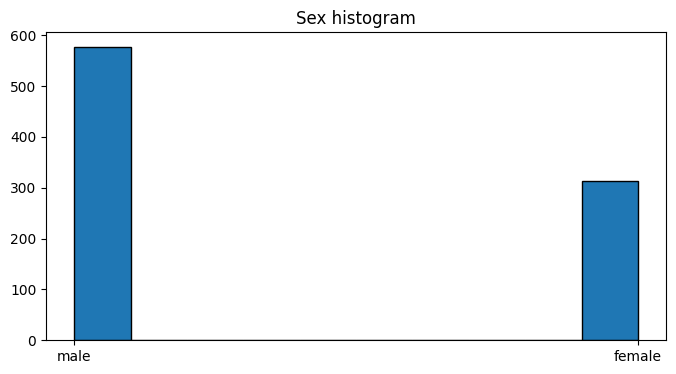

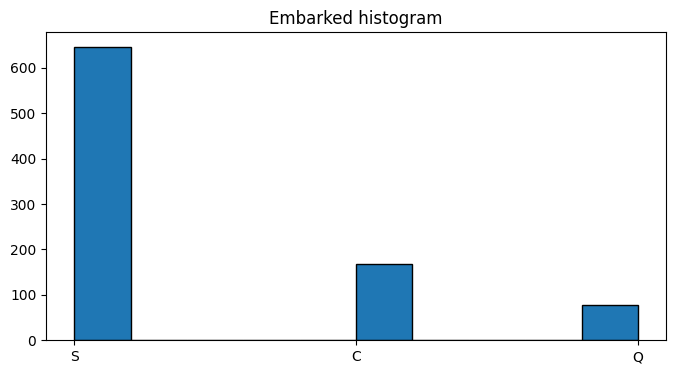

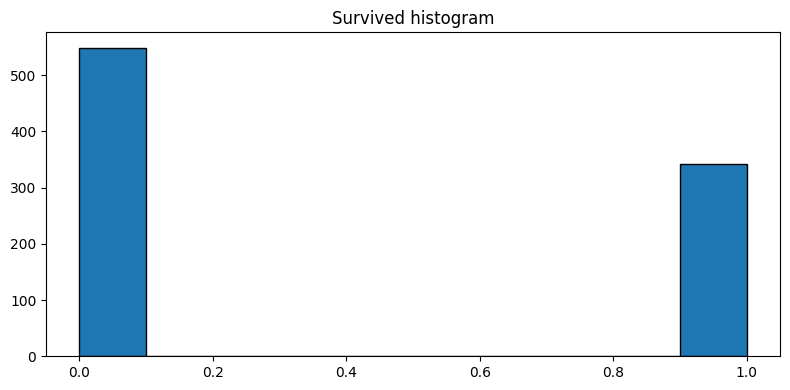

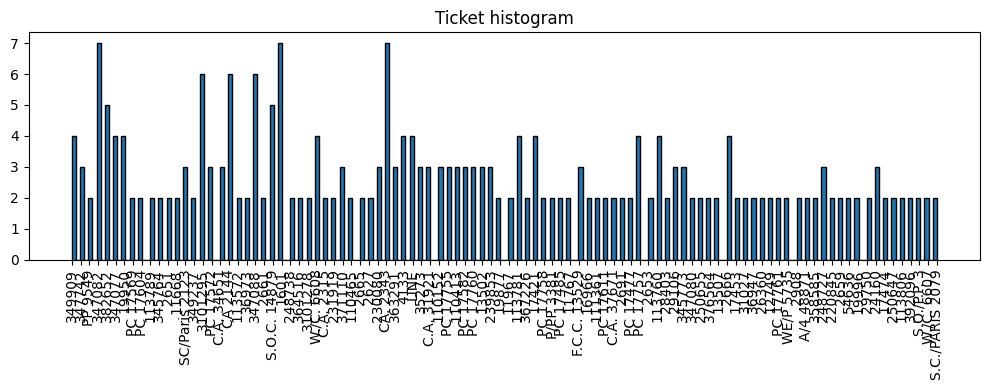

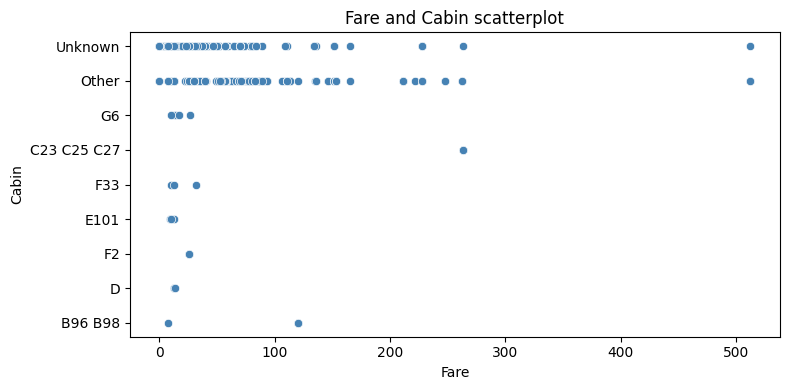

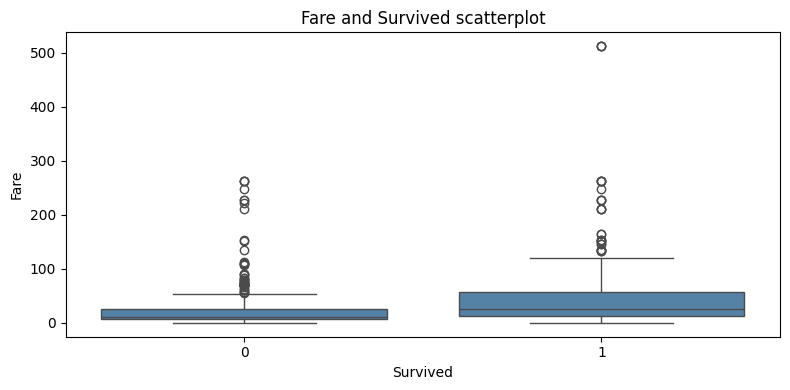

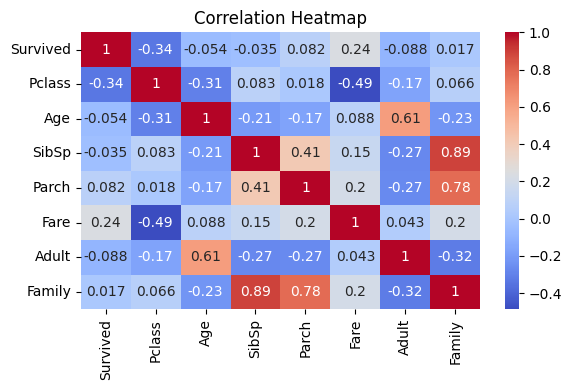

In [113]:
plt.figure(figsize=(8, 4))
plt.title('Age histogram')
plt.hist(titanic_data['Age'], edgecolor='black', bins=65)

plt.figure(figsize=(8, 4))
plt.title('Parch histogram')
plt.hist(titanic_data['Parch'], edgecolor='black', bins=20)

plt.figure(figsize=(8, 4))
plt.title('Sib histogram')
plt.hist(titanic_data['SibSp'], edgecolor='black', bins=20)

plt.figure(figsize=(8, 4))
plt.title('Age and Fare scatterplot')
sns.scatterplot(titanic_data, x='Age', y='Fare', color='steelblue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.title('Fare histogram')
plt.hist(titanic_data['Fare'], edgecolor='black', bins=120)

plt.figure(figsize=(8, 4))
plt.title('Pclass histogram')
plt.hist(titanic_data['Pclass'], edgecolor='black', bins=10)

plt.figure(figsize=(8, 4))
plt.title('Sex histogram')
plt.hist(titanic_data['Sex'], edgecolor='black', bins=10)

plt.figure(figsize=(8, 4))
plt.title('Embarked histogram')
plt.hist(titanic_data['Embarked'], edgecolor='black', bins=10)

plt.figure(figsize=(8, 4))
plt.title('Survived histogram')
plt.hist(titanic_data['Survived'], edgecolor='black')
plt.tight_layout()
plt.show()

ticket_data=titanic_data
top_100=ticket_data.Ticket.value_counts().nlargest(n=100)
is_in_top_100 = ticket_data.Ticket.isin(top_100.index)

plt.figure(figsize=(10, 4))
plt.title('Ticket histogram')
plt.hist(ticket_data.loc[is_in_top_100,'Ticket'], edgecolor='black', bins=210)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


top_9=titanic_data.Cabin.value_counts().nlargest(n=9)
is_in_top_9 = titanic_data.Cabin.isin(top_9.index)
titanic_data.loc[:, 'Cabin'] = titanic_data.Cabin.where(cond=is_in_top_9, other='Other')

plt.figure(figsize=(8, 4))
plt.title('Fare and Cabin scatterplot')
sns.scatterplot(titanic_data, x='Fare', y='Cabin', color='steelblue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.title('Fare and Survived scatterplot')
sns.boxplot(titanic_data, x='Survived', y='Fare', color='steelblue')
plt.tight_layout()
plt.show()

corr_matrix = titanic_data.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Jedynymi kolumnami gdzie jest dużo różnych wartości i często się powtarzają to age i fare. Można zauważyć, że im większa cena biletu tym większa szansa na przeżycie.